# Why are loops over NumPy arrays slow?

In [ ]:
import sys
sys.getsizeof(list())
# GC_HEAD, HEAD, size, capacity, pointer to backing array

56

In [12]:
import numpy as np
import timeit

arr = np.random.rand(1000000)

def for_loop(arr):
    x = 0
    for num in arr:
        x = x + num
    
    return x

%timeit for_loop(arr)


26.5 ms ± 340 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
%timeit np.sum(arr)

107 μs ± 361 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [15]:
import cProfile, pstats

%prun for_loop(arr)

         242 function calls (238 primitive calls) in 0.036 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        3    0.025    0.008    0.025    0.008 socket.py:623(send)
        1    0.006    0.006    0.006    0.006 {method 'execute' of 'sqlite3.Connection' objects}
        1    0.005    0.005    0.005    0.005 2446573676.py:6(for_loop)
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
      2/1    0.000    0.000    0.013    0.013 history.py:1050(_writeout_input_cache)
        1    0.000    0.000    0.000    0.000 attrsettr.py:66(_get_attr_opt)
        2    0.000    0.000    0.000    0.000 {method '__exit__' of 'sqlite3.Connection' objects}
        1    0.000    0.000    0.000    0.000 inspect.py:3133(_bind)
      2/1    0.000    0.000    0.013    0.013 history.py:1066(writeout_cache)
        4    0.000    0.000    0.000    0.000 enum.py:1550(__or__)
        1    0.000    0.00

Matplotlib is building the font cache; this may take a moment.


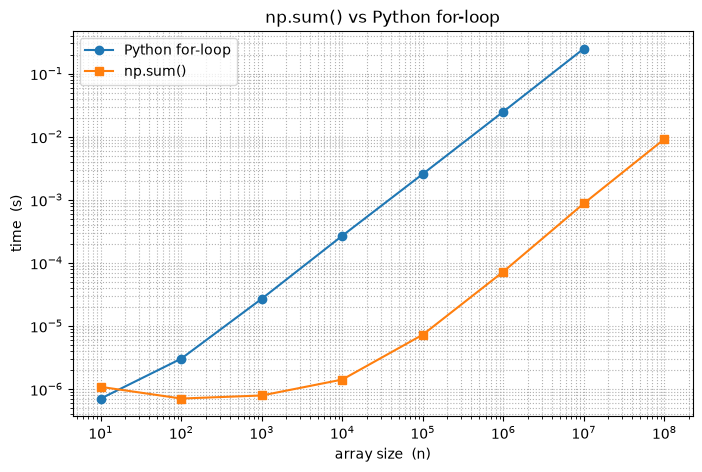

At n=10,000,000: loop is 284x slower than np.sum()


In [16]:
import time
import numpy as np
import matplotlib.pyplot as plt

def best_time(fn, repeats=3):
    """Fastest of `repeats` runs — best-of-N filters out scheduler noise."""
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        best = min(best, time.perf_counter() - t0)
    return best

def python_loop_sum(a):
    total = 0
    for x in a:          # each x is re-boxed into a Python int object
        total += x
    return total

# Sizes 10^1 ... 10^9
sizes = [10**x for x in range(1, 10)]

# The pure-Python loop is ~100x+ slower per element, so cap it:
#   10^7 loop  -> ~1 s         10^9 loop  -> ~100 s
# And a 10^9 int64 array is 8 GB of RAM. Bump these only if you can afford it.
LOOP_MAX = 10**7
SUM_MAX  = 10**8

loop_sizes, loop_times = [], []
sum_sizes,  sum_times  = [], []

for n in sizes:
    a = np.arange(n, dtype=np.int64)
    if n <= SUM_MAX:
        sum_sizes.append(n)
        sum_times.append(best_time(lambda a=a: np.sum(a)))
    if n <= LOOP_MAX:
        loop_sizes.append(n)
        loop_times.append(best_time(lambda a=a: python_loop_sum(a)))
    del a

plt.figure(figsize=(8, 5))
plt.loglog(loop_sizes, loop_times, "o-", label="Python for-loop")
plt.loglog(sum_sizes,  sum_times,  "s-", label="np.sum()")
plt.xlabel("array size  (n)")
plt.ylabel("time  (s)")
plt.title("np.sum() vs Python for-loop")
plt.legend()
plt.grid(True, which="both", ls=":")
plt.show()

# Speedup at the largest common size
common = min(LOOP_MAX, SUM_MAX)
print(f"At n={common:,}: loop is "
      f"{loop_times[loop_sizes.index(common)] / sum_times[sum_sizes.index(common)]:.0f}x "
      f"slower than np.sum()")

## Explanation

In the for loop, we do the following for each element:

1. read a raw int64 from the buffer
2. box it into a PyObject
3. dispatch total.__add__
4. rebox the new running total
5. interpreter loop overhead

$T_{\text{loop}} \approx An + C$:
- $A$: per-element overhead
- $C$ fixed call overhead.


By constract, in np.sum(), we have one compiled C loop:
1. enter C loop once (fixed cost)
2. tight loop over raw buffer:
    - no boxing, no dispatch
    - SIND: 4-8 adds per instruction
3. Box result at the end

$T_{\text{sum}} \approx (B/V)n + D$
- $B$: per-element overhead
- $V$ number of SIMD lanes
- $D$: fixed overhead

$B, D << A$